In [46]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

In [47]:
import warnings
warnings.filterwarnings('ignore')

In [48]:
df_appliction = pd.read_csv('./data/cleaned_data/applications.csv')

In [49]:
df_completions = pd.read_csv('./data/cleaned_data/completions.csv')

In [50]:
df_merged = df_appliction.merge(right = df_completions, how = 'inner', on='unique_id', suffixes=('_app' , '_comp'))

In [51]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7929 entries, 0 to 7928
Data columns (total 32 columns):
 #   Column                                                                               Non-Null Count  Dtype  
---  ------                                                                               --------------  -----  
 0   unique_id                                                                            7929 non-null   object 
 1   subscription_status                                                                  7929 non-null   object 
 2   voyage_role                                                                          7929 non-null   object 
 3   gender                                                                               7929 non-null   object 
 4   goal                                                                                 7929 non-null   object 
 5   source                                                                               7929 

In [52]:
# Step 2: Normalize 'completed_voyage'
df_merged['completed_voyage'] = df_merged['completed_voyage'].replace({
    'Yes': 'Yes',
    'TBD' : 'Yes',
    'No': 'No',
    'undefined': 'No'
})
# Step 3: Convert 'completed_voyage' to binary target
df_merged['completed_voyage'] = df_merged['completed_voyage'].map({'Yes': 1, 'No': 0})

In [53]:
# Inspect the columns to identify categorical fields to be binary encoded
categorical_columns = df_merged.select_dtypes(include='object').columns.tolist()

# Display merged DataFrame head and the identified categorical columns
df_merged.head(), categorical_columns

(                          unique_id subscription_status   voyage_role  gender  \
 0  dadffe486c63fc05d8b3afee2c4dc132              Active  Scrum Master  FEMALE   
 1  4e1e9195a8bdc244876ffd8fb954e5c8              Active     Developer    MALE   
 2  4e1e9195a8bdc244876ffd8fb954e5c8              Active     Developer    MALE   
 3  56a8ef8425ff0595bd660065cae07793              Active  Scrum Master  FEMALE   
 4  56a8ef8425ff0595bd660065cae07793              Active  Scrum Master  FEMALE   
 
               goal            source country_name_from_country  \
 0  GAIN EXPERIENCE   The Job Hackers                    Canada   
 1  GAIN EXPERIENCE  PERSONAL NETWORK                     India   
 2  GAIN EXPERIENCE  PERSONAL NETWORK                     India   
 3  GAIN EXPERIENCE  PERSONAL NETWORK            United Kingdom   
 4  GAIN EXPERIENCE  PERSONAL NETWORK            United Kingdom   
 
   voyage_from_voyage_signups  application_age_in_days application_day_of_week  \
 0                  

In [54]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7929 entries, 0 to 7928
Data columns (total 32 columns):
 #   Column                                                                               Non-Null Count  Dtype  
---  ------                                                                               --------------  -----  
 0   unique_id                                                                            7929 non-null   object 
 1   subscription_status                                                                  7929 non-null   object 
 2   voyage_role                                                                          7929 non-null   object 
 3   gender                                                                               7929 non-null   object 
 4   goal                                                                                 7929 non-null   object 
 5   source                                                                               7929 

In [55]:
from category_encoders import BinaryEncoder
import pandas as pd

# Step 1: Binary encode only categorical object columns
categorical_cols = df_merged.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['unique_id', 'timestamp']]

# Apply BinaryEncoder only to those categorical columns
binary_encoder = BinaryEncoder(cols=categorical_cols, return_df=True)
df_encoded = binary_encoder.fit_transform(df_merged)

# Step 2: Convert timestamp to datetime
df_encoded['timestamp'] = pd.to_datetime(df_merged['timestamp'])

# Step 3: Sort data
df_encoded = df_encoded.sort_values(by=['unique_id', 'timestamp'])

# Step 4: Select features
non_feature_cols = ['unique_id', 'subscription_status_dt',
                    'certificate_issue_date', 'application_date', 'updated_voyage_start_date']
feature_cols = [col for col in df_encoded.columns if col not in non_feature_cols + ['completed_voyage']]

# Step 5: Prepare sequences
sequence_data = []
sequence_targets = []

for uid, group in df_encoded.groupby('unique_id'):
    if len(group) < 2:
        continue
    X = group[feature_cols].to_numpy()
    y = group['completed_voyage'].to_numpy()
    sequence_data.append(X)
    sequence_targets.append(y)

# Summary
num_sequences = len(sequence_data)
seq_lengths = [len(seq) for seq in sequence_data]
min_len, max_len = min(seq_lengths), max(seq_lengths)

(num_sequences, min_len, max_len, len(feature_cols))
from category_encoders import BinaryEncoder
import pandas as pd

# Step 1: Binary encode only categorical object columns
categorical_cols = df_merged.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['unique_id', 'timestamp_x', 'timestamp_y']]

# Apply BinaryEncoder only to those categorical columns
binary_encoder = BinaryEncoder(cols=categorical_cols, return_df=True)
df_encoded = binary_encoder.fit_transform(df_merged)

# Step 2: Convert timestamp to datetime
df_encoded['timestamp'] = pd.to_datetime(df_merged['timestamp'])

# Step 3: Sort data
df_encoded = df_encoded.sort_values(by=['unique_id', 'timestamp'])

# Step 4: Select features
non_feature_cols = ['unique_id', 'timestamp', 'subscription_status_dt',
                    'certificate_issue_date', 'application_date', 'updated_voyage_start_date']
feature_cols = [col for col in df_encoded.columns if col not in non_feature_cols + ['completed_voyage']]

# Step 5: Prepare sequences
sequence_data = []
sequence_targets = []

for uid, group in df_encoded.groupby('unique_id'):
    if len(group) < 2:
        continue
    X = group[feature_cols].to_numpy()
    y = group['completed_voyage'].to_numpy()
    sequence_data.append(X)
    sequence_targets.append(y)

# Summary
num_sequences = len(sequence_data)
seq_lengths = [len(seq) for seq in sequence_data]
min_len, max_len = min(seq_lengths), max(seq_lengths)

(num_sequences, min_len, max_len, len(feature_cols))


(666, 2, 224, 112)

In [56]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from torch.nn.utils import clip_grad_norm_
import copy
from torch.nn.utils.rnn import pad_sequence

# Dataset prep — Clean & normalize BEFORE converting to tensor
# Convert to tensors and pad
sequence_tensor = [torch.tensor(seq, dtype=torch.float32) for seq in sequence_data]
target_tensor = [torch.tensor(seq, dtype=torch.float32) for seq in sequence_targets]

# Pad with zeros to the right (post-padding)
X_tensor = pad_sequence(sequence_tensor, batch_first=True)
y_tensor = pad_sequence(target_tensor, batch_first=True)

# Normalize X_tensor
X_tensor = torch.nan_to_num(X_tensor, nan=0.0, posinf=1e3, neginf=-1e3)
X_tensor = torch.clamp(X_tensor, -10, 10)
mean = X_tensor.mean(dim=(0, 1), keepdim=True)
std = X_tensor.std(dim=(0, 1), keepdim=True) + 1e-6
X_tensor = (X_tensor - mean) / std


class VoyageDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = VoyageDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
train_ds, test_ds = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# Updated model WITHOUT sigmoid
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.dropout(x)
        return self.classifier(x).squeeze(-1)  # shape: (batch, seq)

model = LSTMClassifier(X_tensor.shape[2])
criterion = nn.BCEWithLogitsLoss()  # handles raw logits directly
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
best_loss = float('inf')
patience = 3
wait = 0
best_model = copy.deepcopy(model.state_dict())

for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)

        if torch.isnan(logits).any() or torch.isinf(logits).any():
            continue

        yb = torch.clamp(yb, 0, 1)
        loss = criterion(logits, yb)

        if torch.isnan(loss): continue

        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    
    # Move early stopping OUTSIDE the inner loop
    if total_loss < best_loss:
        best_loss = total_loss
        wait = 0
        best_model = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break
            

    
model.load_state_dict(best_model)
# Evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.numel()

print(f"Test Accuracy: {correct / total:.4f}")


Epoch 1, Loss: 6.9948
Epoch 2, Loss: 1.4269
Epoch 3, Loss: 0.6922
Epoch 4, Loss: 0.5835
Epoch 5, Loss: 0.5253
Epoch 6, Loss: 0.4810
Epoch 7, Loss: 0.4512
Epoch 8, Loss: 0.4208
Epoch 9, Loss: 0.4019
Epoch 10, Loss: 0.3685
Test Accuracy: 0.9938


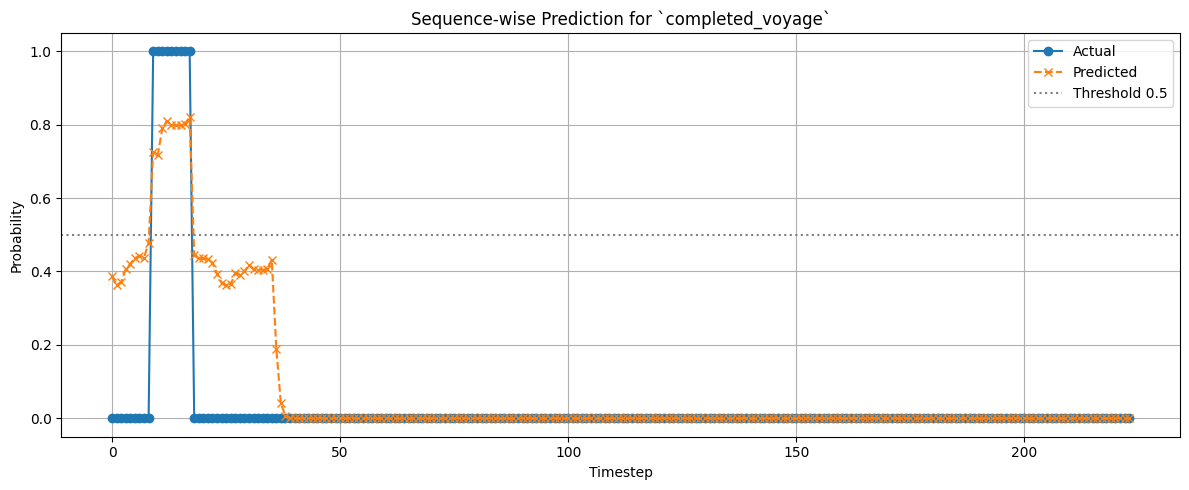

In [57]:
import matplotlib.pyplot as plt

# Pick a test sample (e.g. first one in test set)
sample_x, sample_y = test_ds[0]
sample_x = sample_x.unsqueeze(0)  # add batch dim: (1, seq_len, features)

# Predict
model.eval()
with torch.no_grad():
    logits = model(sample_x)
    probs = torch.sigmoid(logits).squeeze().numpy()  # shape: (seq_len,)
    ground_truth = sample_y.numpy()

# Visualize
plt.figure(figsize=(12, 5))
plt.plot(ground_truth, label='Actual', linestyle='-', marker='o')
plt.plot(probs, label='Predicted', linestyle='--', marker='x')
plt.axhline(0.5, color='gray', linestyle=':', label='Threshold 0.5')
plt.title("Sequence-wise Prediction for `completed_voyage`")
plt.xlabel("Timestep")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

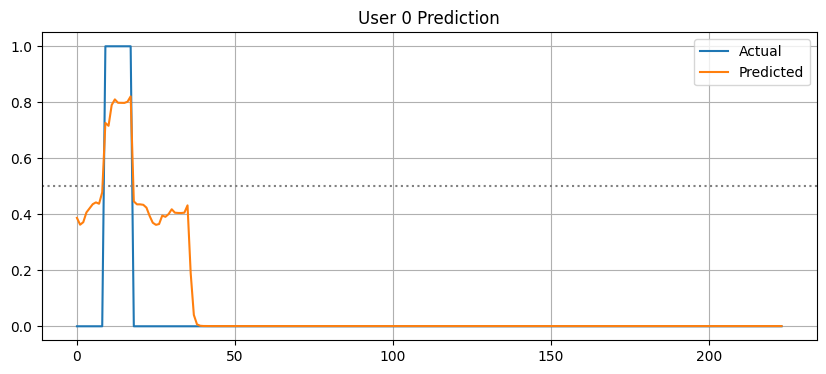

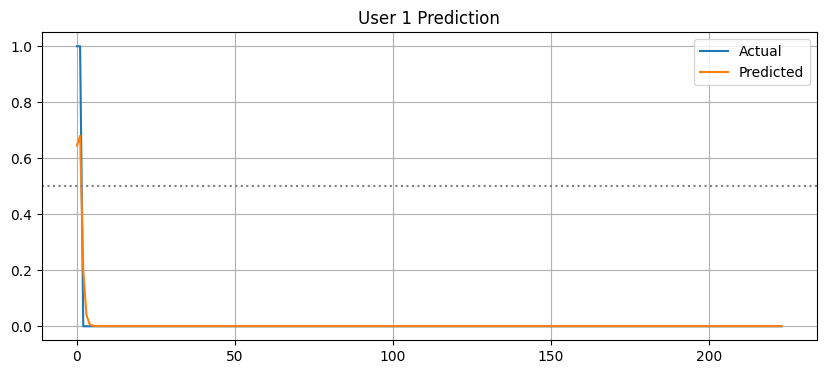

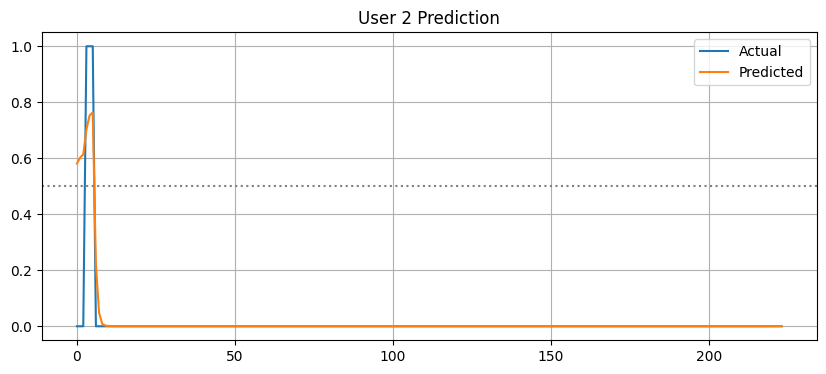

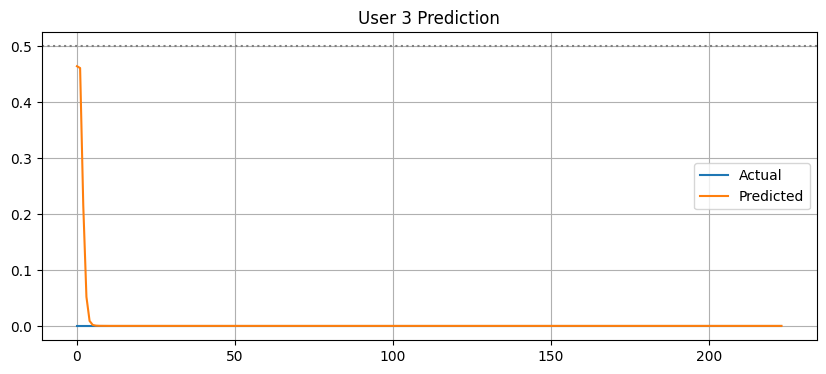

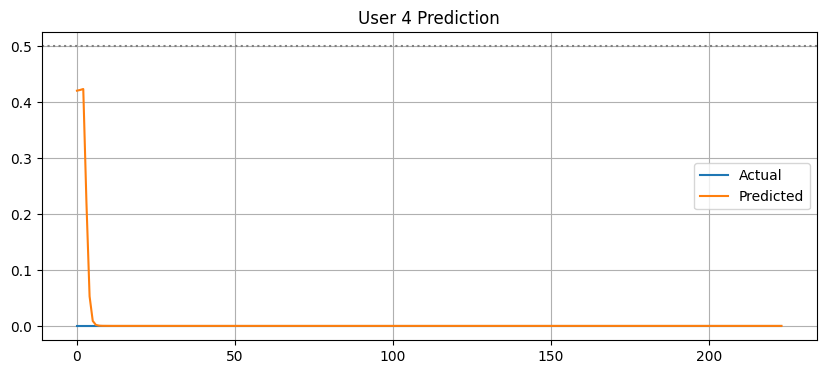

In [58]:
for i in range(5):  # show 5 users
    x, y = test_ds[i]
    logits = model(x.unsqueeze(0))
    probs = torch.sigmoid(logits).squeeze().detach().numpy()
    
    plt.figure(figsize=(10, 4))
    plt.plot(y.numpy(), label='Actual')
    plt.plot(probs, label='Predicted')
    plt.axhline(0.5, linestyle=':', color='gray')
    plt.title(f"User {i} Prediction")
    plt.legend()
    plt.grid(True)
    plt.show()


In [59]:
# Step 1: Parse and filter data
df_forecast = df_merged.copy()
df_forecast['timestamp'] = pd.to_datetime(df_forecast['timestamp'])
df_forecast = df_forecast[df_forecast['completed_voyage'] == 1]

# Step 2: Monthly aggregation
monthly_counts = df_forecast.set_index('timestamp').resample('M').size().reset_index(name='voyage_completions')

# Step 3: Rename columns for Prophet
df_prophet = monthly_counts.rename(columns={'timestamp': 'ds', 'voyage_completions': 'y'})


In [29]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 35.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 KB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.3/932.3 KB 13.3 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


11:01:25 - cmdstanpy - INFO - Chain [1] start processing
11:01:26 - cmdstanpy - INFO - Chain [1] done processing


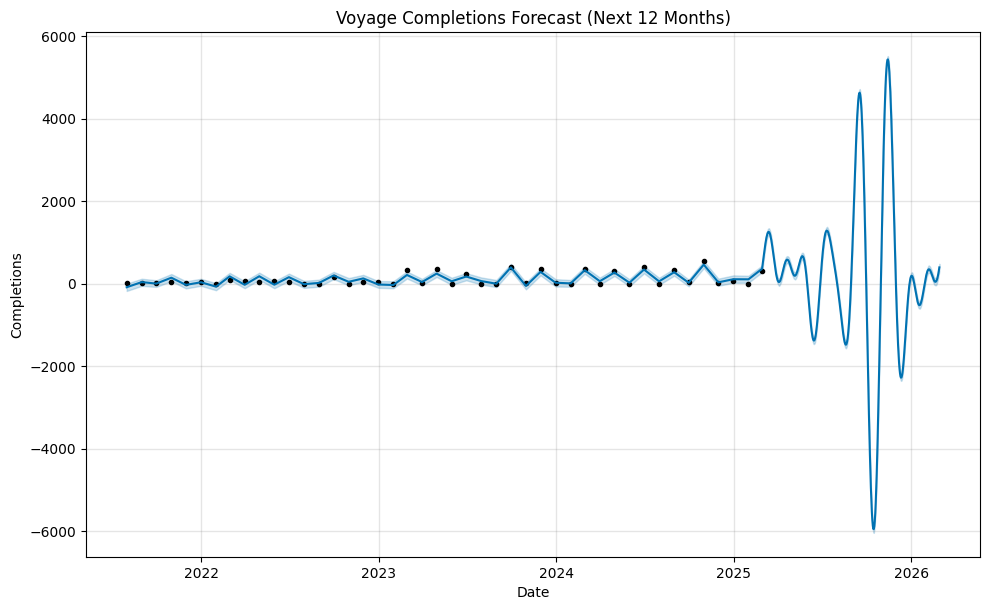

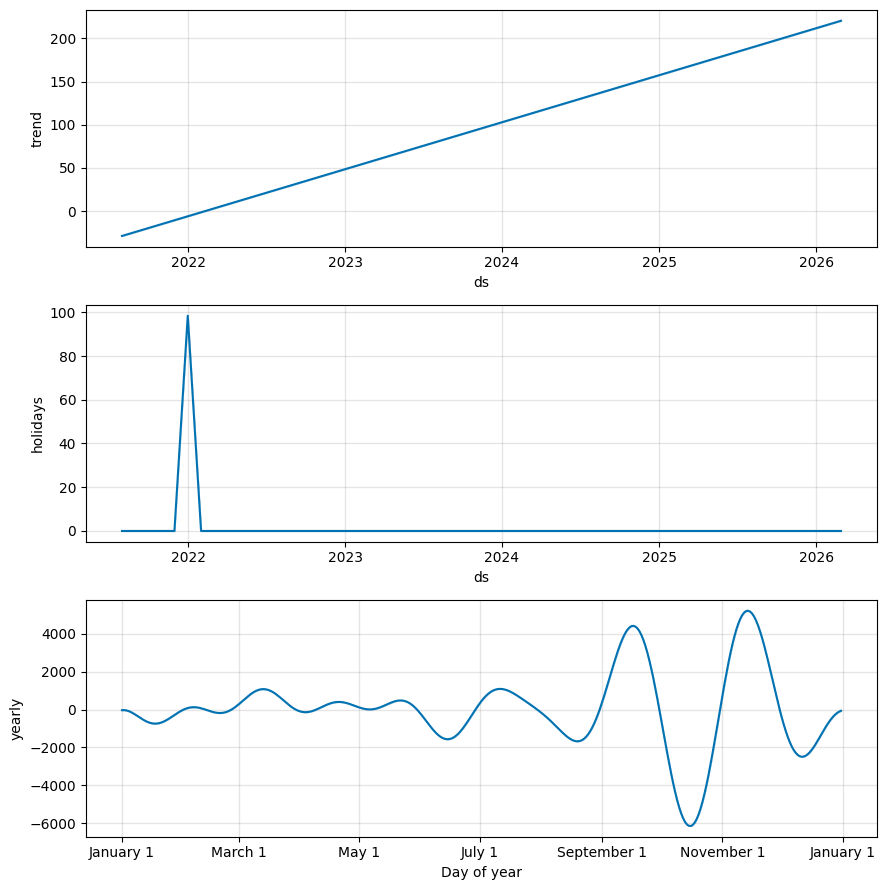

,ds,yhat,yhat_lower,yhat_upper
397,2026-02-17,78.133516,-14.203461,158.964304
398,2026-02-18,58.354851,-29.061691,144.098114
399,2026-02-19,46.383317,-35.848873,141.688841
400,2026-02-20,43.419517,-41.050771,130.170416
401,2026-02-21,50.407503,-38.687347,144.749428
402,2026-02-22,68.004377,-25.666338,149.053242
403,2026-02-23,96.558047,10.891452,183.104571
404,2026-02-24,136.093765,52.814738,222.088330
405,2026-02-25,186.309851,101.664507,278.607852
406,2026-02-26,246.582708,166.710201,336.745113


In [72]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Prepare data (already done earlier)
# df_prophet = DataFrame with columns ['ds', 'y']

# Step 2: Initialize and fit Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.add_country_holidays(country_name='US')
model.fit(df_prophet)

# Step 3: Create 12-month future dataframe
future = model.make_future_dataframe(periods=365, freq='D')

# Step 4: Forecast
forecast = model.predict(future)

# Step 5: Plot
fig1 = model.plot(forecast)
plt.title("Voyage Completions Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Completions")
plt.grid(True)
plt.show()

# Optional: Components plot
fig2 = model.plot_components(forecast)
plt.show()

# Optional: Show forecasted numbers
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

In [76]:
# Show all columns for inspection
print(forecast.columns)

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'Christmas Day', 'Christmas Day_lower', 'Christmas Day_upper',
       'Christmas Day (observed)', 'Christmas Day (observed)_lower',
       'Christmas Day (observed)_upper', 'Columbus Day', 'Columbus Day_lower',
       'Columbus Day_upper', 'Independence Day', 'Independence Day_lower',
       'Independence Day_upper', 'Independence Day (observed)',
       'Independence Day (observed)_lower',
       'Independence Day (observed)_upper',
       'Juneteenth National Independence Day',
       'Juneteenth National Independence Day_lower',
       'Juneteenth National Independence Day_upper',
       'Juneteenth National Independence Day (observed)',
       'Juneteenth National Independence Day (observed)_lower',
       'Juneteenth National Independence Day (observed)_upper', 'Labor Day',
       'Labor Day_lower', 'Labor Day_upper', 'Martin Luther King Jr. Day',
       'Martin Luther King Jr. Day_lower', 'Mart

In [79]:


# Focus on the holiday effect column
holiday_effect = forecast[['ds', 'holidays']].copy()
print(holiday_effect)
holiday_effect.head(10)
holiday_effect['holidays'].unique()

            ds  holidays
0   2021-07-31       0.0
1   2021-08-31       0.0
2   2021-09-30       0.0
3   2021-10-31       0.0
4   2021-11-30       0.0
..         ...       ...
404 2026-02-24       0.0
405 2026-02-25       0.0
406 2026-02-26       0.0
407 2026-02-27       0.0
408 2026-02-28       0.0

[409 rows x 2 columns]


array([ 0.00000000e+00,  9.84159540e+01,  4.42746486e-11, -1.58175108e-11,
        1.15838814e-11,  1.99475094e-11,  3.22119252e-11, -1.72763682e-12,
        4.49813364e-11,  3.86562540e-11,  5.75101800e-12,  2.65817370e-11,
       -1.62705816e-11])

In [80]:
# Filter days where holidays had a noticeable effect
significant_holidays = holiday_effect_future[holiday_effect_future['holidays'].abs() > 1]

# Sort by magnitude
significant_holidays = significant_holidays.sort_values(by='holidays', ascending=False)
print(significant_holidays.head(10))

Empty DataFrame
Columns: [ds, holidays]
Index: []


In [74]:
# Only forecasted dates (not in original df)
forecast_dates = forecast[forecast['ds'] > df_prophet['ds'].max()]
holiday_effect_future = forecast_dates[['ds', 'holidays']].copy()

In [81]:
significant = holiday_effect[np.abs(holiday_effect['holidays']) > 1e-2]
print(significant.sort_values(by='holidays', ascending=False))


          ds   holidays
5 2021-12-31  98.415954
